## Neighborhood Population Distribution

This notebook adapts the proportional-split / MapPLUTO-weighted population apportionment workflow from [`02_flood_vulnerability_proportional_split.ipynb`](../../content/Tutorials/02_flood_vulnerability_proportional_split.ipynb) to the two study neighborhoods defined in `NYCPathways.ipynb`: Jackson Heights and Bedford-Stuyvesant.

Instead of apportioning population into a flood zone, we apportion population into each neighborhood boundary, first using simple area-weighted proportional split from Census block groups, then refining with MapPLUTO residential unit counts at the tax-lot level.

In [1]:
import geopandas as gpd
import pandas as pd
import requests
import matplotlib.pyplot as plt
from cdptools import utils

utils.set_axis_off()

WORKING_CRS = 2263  # NAD83 State Plane Long Island (feet), matches NYCPathways.ipynb

## Preparing data

We reuse the neighborhood boundaries already exported by `NYCPathways.ipynb` (`Data/boundary_bedstuy.geojson` and `Data/boundary_jacksonheights.geojson`), each dissolved to a single polygon and already in our working CRS. We keep them in a `boundaries` dict keyed the same way as in `NYCPathways.ipynb` so the rest of the workflow can loop over neighborhoods generically.

In [2]:
neighborhoods = {
    "bedstuy": "Bedford-Stuyvesant",
    "jacksonheights": "Jackson Heights",
}

boundaries = {
    key: gpd.read_file(f"Data/boundary_{key}.geojson").to_crs(WORKING_CRS)
    for key in neighborhoods
}

study_area = gpd.GeoSeries(
    [b.geometry.iloc[0] for b in boundaries.values()], crs=WORKING_CRS
).union_all()

Jackson Heights and Bed-Stuy don't align neatly to a single zip code the way Far Rockaway did in the tutorial, so instead of a `where` clause we filter the Census block groups with a spatial `mask` against the combined study area. This is pushed down at read time, so we still avoid loading the full citywide file into memory.

<Axes: >

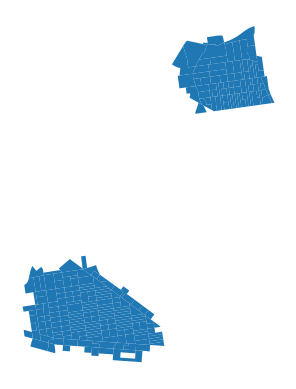

In [3]:
census_gdf = gpd.read_file(
    "../../content/Data/census_nyc_sp.fgb", mask=study_area
).to_crs(WORKING_CRS)

census_gdf.plot()

We'll also pull MapPLUTO tax lots for a more granular, residential-unit-weighted estimate, same as the tutorial. Since our neighborhoods span parts of Brooklyn and Queens rather than a single zip code, we filter the ArcGIS endpoint spatially (by bounding-box envelope, in the same way `where="ZipCode = ..."` filtered attributes in the tutorial) instead of by an attribute clause, then clip precisely to each boundary afterward.

In [4]:
def fetch_pluto_for_bounds(bounds, layer_wkid=WORKING_CRS):
    """Fetch MapPLUTO tax lots intersecting a bounding box (xmin, ymin, xmax, ymax)."""
    base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
    xmin, ymin, xmax, ymax = bounds

    all_features, offset = [], 0
    while True:
        params = {
            "geometry": f"{xmin},{ymin},{xmax},{ymax}",
            "geometryType": "esriGeometryEnvelope",
            "inSR": layer_wkid,
            "spatialRel": "esriSpatialRelIntersects",
            "outFields": "CD,LandUse,UnitsRes,BCTCB2020,BCT2020",
            "returnGeometry": "true",
            "outSR": layer_wkid,
            "resultOffset": offset,
            "resultRecordCount": 2000,
            "f": "geojson",
        }
        r = requests.get(base_url, params=params)
        r.raise_for_status()
        fc = r.json()
        if "error" in fc:
            raise RuntimeError(fc["error"])
        feats = fc.get("features", [])
        all_features.extend(feats)
        if len(feats) < 2000:
            break
        offset += 2000

    return gpd.GeoDataFrame.from_features(all_features, crs=f"EPSG:{layer_wkid}")


pluto_gdfs = {}
for key, boundary in boundaries.items():
    pluto_gdfs[key] = fetch_pluto_for_bounds(boundary.total_bounds)
    print(f"{key}: {len(pluto_gdfs[key])} tax lots fetched")

bedstuy: 22413 tax lots fetched
jacksonheights: 10693 tax lots fetched


<Axes: >

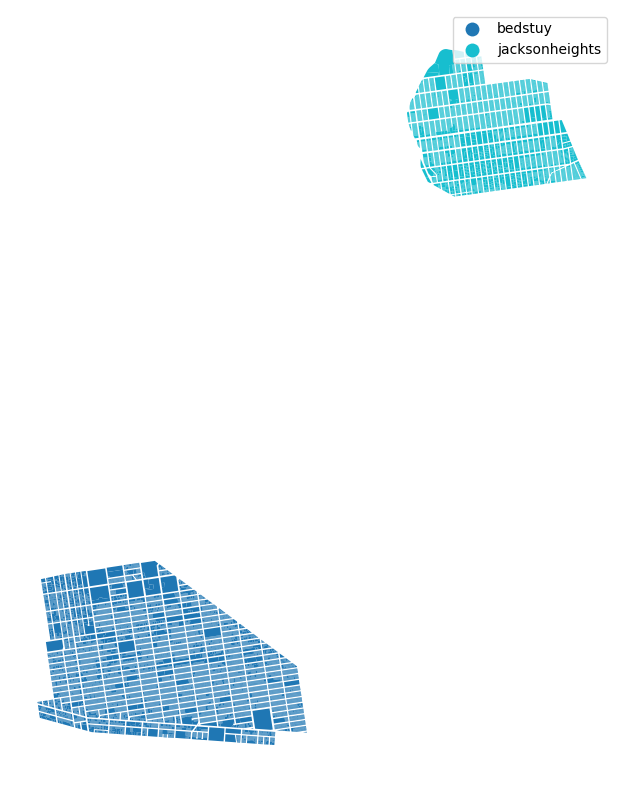

In [5]:
# clip each PLUTO pull to its precise neighborhood boundary and tag with the neighborhood key
clipped = []
for key, gdf in pluto_gdfs.items():
    lots = gpd.clip(gdf, boundaries[key])
    lots["neighborhood"] = key
    clipped.append(lots)

pluto_gdf = pd.concat(clipped, ignore_index=True)
pluto_gdf = gpd.GeoDataFrame(pluto_gdf, crs=WORKING_CRS)
pluto_gdf.plot(column="neighborhood", legend=True, figsize=(10, 10))

## Performing Proportional Split

Same approach as the tutorial: build a shared `block_group` ID on both datasets by slicing `BCTCB2020` (PLUTO) and `GISJOIN` (Census) down to the tract + block group digits, then apportion population by area overlap between each Census block group and each neighborhood boundary.

In [6]:
pluto_gdf["block_group"] = pluto_gdf["BCTCB2020"].str[1:8]
census_gdf["block_group"] = census_gdf["GISJOIN"].str[8:]

# area-based proportional split: apportion each block group's population into
# each neighborhood boundary based on fraction of the block group's area covered
records = []
for key, boundary in boundaries.items():
    bg = census_gdf.copy()
    bg["bg_area"] = bg.geometry.area
    bg["overlap_area"] = bg.geometry.intersection(boundary.union_all()).area
    bg["frac_in_neighborhood"] = bg["overlap_area"] / bg["bg_area"]
    bg["pop_in_neighborhood"] = (
        bg["Total Pop (Race/Ethnicity)"] * bg["frac_in_neighborhood"]
    )
    bg["neighborhood"] = key
    records.append(bg[bg["frac_in_neighborhood"] > 0])

bg_split_gdf = pd.concat(records, ignore_index=True)
bg_split_gdf = gpd.GeoDataFrame(bg_split_gdf, crs=WORKING_CRS)

bg_split_gdf.groupby("neighborhood")["pop_in_neighborhood"].sum()

neighborhood
bedstuy           182881.071146
jacksonheights     93945.487741
Name: pop_in_neighborhood, dtype: float64

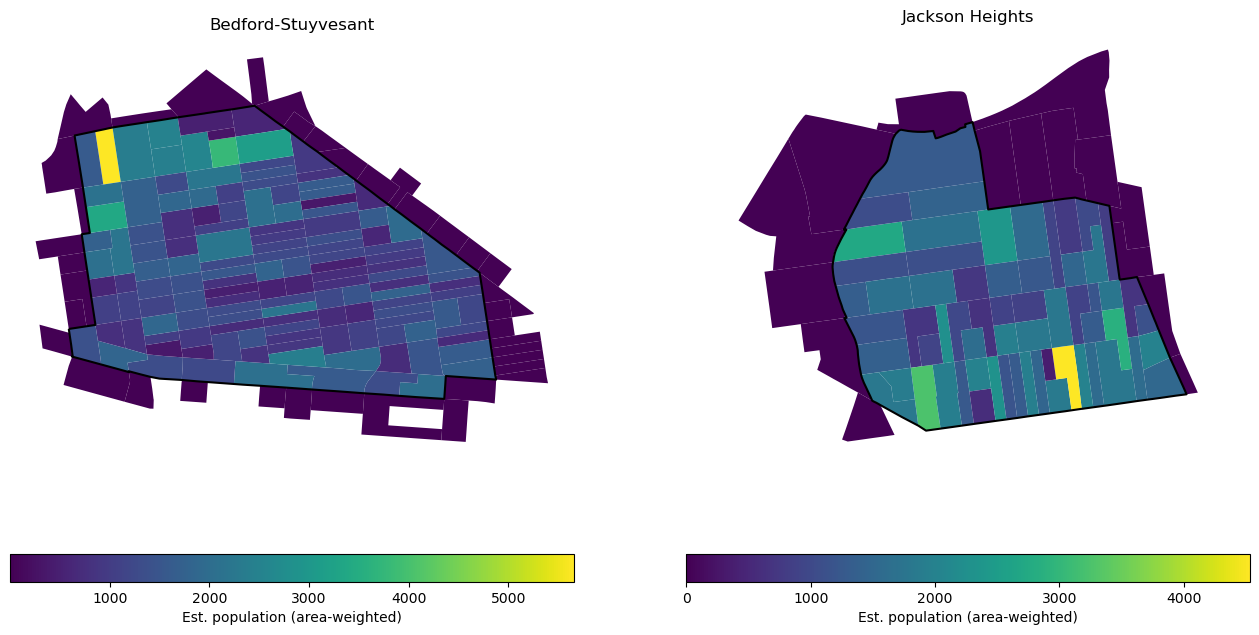

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, key in zip(axes, boundaries):
    subset = bg_split_gdf[bg_split_gdf["neighborhood"] == key]
    subset.plot(
        column="pop_in_neighborhood",
        legend=True,
        ax=ax,
        legend_kwds={"label": "Est. population (area-weighted)", "orientation": "horizontal"},
    )
    boundaries[key].boundary.plot(ax=ax, color="black")
    ax.set_title(neighborhoods[key])

Area-weighted split assumes population is even across a block group, which understates how concentrated residents actually are in multi-family buildings. As in the tutorial, we refine the estimate by apportioning each block group's population to its MapPLUTO tax lots in proportion to residential units (`UnitsRes`), rather than by raw area.

In [8]:
def apportion_population_to_tax_lot(row, pluto_gdf, census_gdf):
    """Apportion population in a census block group to tax lots based on residential units."""
    block_group = row["block_group"]
    if block_group not in census_gdf["block_group"].values:
        return 0
    population = census_gdf[census_gdf["block_group"] == block_group][
        "Total Pop (Race/Ethnicity)"
    ].values[0]
    pluto_subset = pluto_gdf[pluto_gdf["block_group"] == block_group]
    total_units = pluto_subset["UnitsRes"].sum()
    if total_units == 0:
        return 0
    return row["UnitsRes"] / total_units * population


pluto_gdf["est_pop_per_lot"] = pluto_gdf.apply(
    lambda row: apportion_population_to_tax_lot(row, pluto_gdf, census_gdf), axis=1
)

pluto_gdf.groupby("neighborhood")["est_pop_per_lot"].sum()

neighborhood
bedstuy           168572.099078
jacksonheights     70887.900922
Name: est_pop_per_lot, dtype: float64

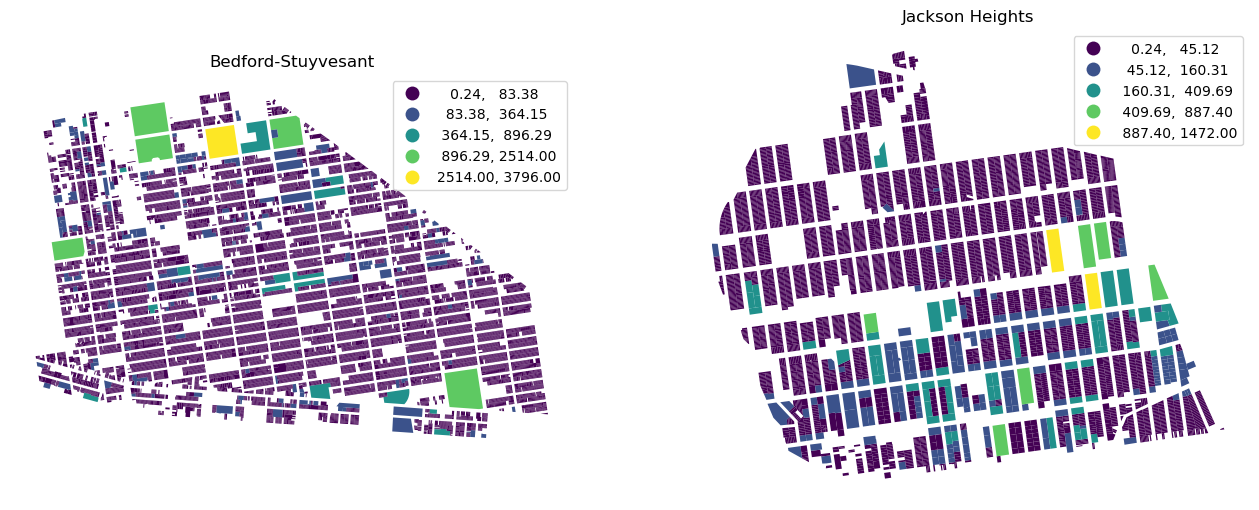

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, key in zip(axes, boundaries):
    subset = pluto_gdf[(pluto_gdf["neighborhood"] == key) & (pluto_gdf["est_pop_per_lot"] > 0)]
    subset.plot(
        column="est_pop_per_lot",
        legend=True,
        scheme="naturalbreaks",
        ax=ax,
    )
    ax.set_title(neighborhoods[key])

As in the tutorial, we can render a dot-density map (one dot per two residents) to visualize where people are actually concentrated within each neighborhood, rather than relying on a choropleth of block groups.

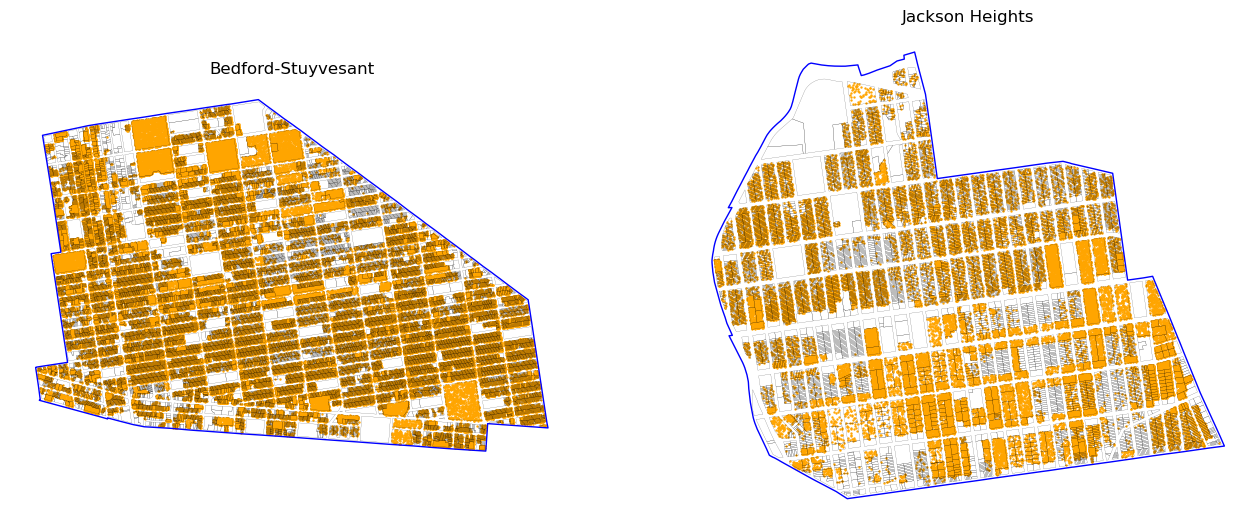

In [10]:
pluto_gdf["pop_points"] = pluto_gdf.apply(
    lambda row: (
        utils.random_points_in_geom(row.geometry, row["est_pop_per_lot"] / 2)
        if row["est_pop_per_lot"] > 0
        else None
    ),
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, key in zip(axes, boundaries):
    subset = pluto_gdf[pluto_gdf["neighborhood"] == key]
    subset.boundary.plot(color="black", linewidth=0.1, ax=ax)
    subset.set_geometry("pop_points").plot(color="orange", markersize=0.5, ax=ax)
    boundaries[key].boundary.plot(ax=ax, color="blue", linewidth=1)
    ax.set_title(neighborhoods[key])

## Comparing estimates and exporting results

Finally, compare the area-weighted and PLUTO-weighted population totals per neighborhood, and write both the block-group-level and tax-lot-level results out to `outputs/` (as in `NYCPathways.ipynb`) for downstream use — e.g. as the population input to the Grasshopper trip-generation analysis.

In [11]:
summary = pd.DataFrame(
    {
        "area_weighted_pop": bg_split_gdf.groupby("neighborhood")["pop_in_neighborhood"].sum(),
        "pluto_weighted_pop": pluto_gdf.groupby("neighborhood")["est_pop_per_lot"].sum(),
    }
)
summary.index = summary.index.map(neighborhoods)
summary["difference"] = summary["pluto_weighted_pop"] - summary["area_weighted_pop"]
summary

,area_weighted_pop,pluto_weighted_pop,difference
neighborhood,,,
Bedford-Stuyvesant,182881.071146,168572.099078,-14308.972068
Jackson Heights,93945.487741,70887.900922,-23057.586819


In [12]:
import os

os.makedirs("outputs", exist_ok=True)

bg_split_gdf.drop(columns="pop_points", errors="ignore").to_crs(4326).to_file(
    "outputs/population_by_blockgroup.geojson", driver="GeoJSON"
)
pluto_gdf.drop(columns="pop_points").to_crs(4326).to_file(
    "outputs/population_by_taxlot.geojson", driver="GeoJSON"
)
summary.to_csv("outputs/population_summary.csv")

In [13]:
pluto_gdf[pluto_gdf["neighborhood"] == "bedstuy"].drop(columns="pop_points").to_crs(4326).to_file(
    "outputs/population_by_taxlot_bedstuy.geojson", driver="GeoJSON"
)

## Snapping population points to the walk network



In [ ]:
import requests

#I am fetching the MapPluto data because its very large to import and is eaiser to fetch only the neighborhoods I need rather than filtering here.
def fetch_pluto_for_bounds(bounds, layer_wkid=WORKING_CRS):
    """Fetch MapPLUTO tax lots intersecting a bounding box (xmin, ymin, xmax, ymax)."""
    base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
    xmin, ymin, xmax, ymax = bounds

    all_features, offset = [], 0
    while True:
        params = {
            "geometry": f"{xmin},{ymin},{xmax},{ymax}",
            "geometryType": "esriGeometryEnvelope",
            "inSR": layer_wkid,
            "spatialRel": "esriSpatialRelIntersects",
            "outFields": "CD,LandUse,UnitsRes,BCTCB2020,BCT2020",
            "returnGeometry": "true",
            "outSR": layer_wkid,
            "resultOffset": offset,
            "resultRecordCount": 2000,
            "f": "geojson",
        }
        r = requests.get(base_url, params=params)
        r.raise_for_status()
        fc = r.json()
        if "error" in fc:
            raise RuntimeError(fc["error"])
        feats = fc.get("features", [])
        all_features.extend(feats)
        if len(feats) < 2000:
            break
        offset += 2000

    return gpd.GeoDataFrame.from_features(all_features, crs=f"EPSG:{layer_wkid}")


pluto_gdfs = {}
for key, boundary in boundaries.items():
    pluto_gdfs[key] = fetch_pluto_for_bounds(boundary.total_bounds)
    print(f"{key}: {len(pluto_gdfs[key])} tax lots fetched")

bedstuy: 22413 tax lots fetched
jacksonheights: 10693 tax lots fetched
